# Credit Card Fraud Detection using Machine Learning

## Project Objective
Detect fraudulent credit card transactions using machine learning while handling class imbalance.

## Machine Learning Pipeline Overview
1. Problem Statement
2. Dataset Understanding
3. EDA
4. Class Imbalance Analysis
5. SMOTE
6. Feature Scaling
7. Model Training
8. Model Comparison
9. Hyperparameter Tuning
10. ROC Curve Comparison
11. Feature Importance
12. Model Saving
13. Conclusion

## Problem Statement

Credit card fraud detection is a critical problem in financial systems. Fraudulent transactions represent a very small fraction of total transactions, which creates a highly imbalanced dataset.

The goal of this project is to build a machine learning model capable of detecting fraudulent transactions while minimizing false positives.

This project focuses on:
- Handling class imbalance
- Building predictive models
- Optimizing models using hyperparameter tuning
- Evaluating performance using appropriate metrics such as Recall, Precision, and ROC-AUC.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Step 2 — Load Dataset

In [4]:
data = pd.read_csv(r"E:\final interview preparetion\ML project\ml project on credit card froud detection\creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Description

The dataset contains anonymized credit card transactions made by European cardholders.

Key characteristics of the dataset:

- Total transactions: ~284,807
- Fraudulent transactions: 492
- Highly imbalanced dataset (fraud cases are less than 1%)

Most features are PCA-transformed variables (V1, V2, ... V28) to protect customer privacy.

Important columns:
- `Time` – seconds elapsed between transactions
- `Amount` – transaction amount
- `Class` – target variable (0 = normal, 1 = fraud)

In [5]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
data = pd.read_csv(r"E:\final interview preparetion\ML project\ml project on credit card froud detection\creditcard.csv")

data = data.fillna(data.mean())

## Step 3 — Dataset Information

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Step 4 — Class Distribution

In [8]:
data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Step 5 — Visualize Class Imbalance

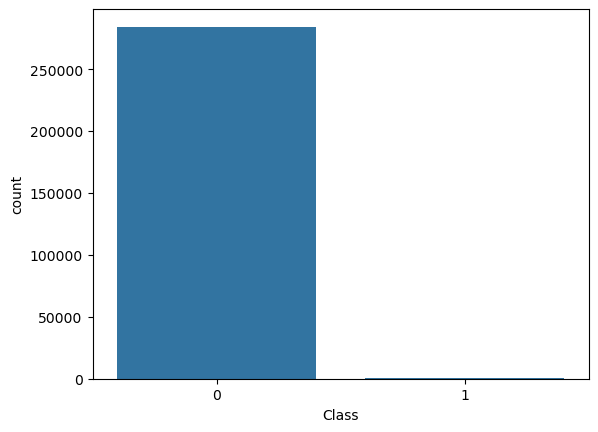

In [9]:
sns.countplot(x='Class', data=data)
plt.show()

## Why Class Imbalance is a Problem

In fraud detection, fraudulent transactions are extremely rare compared to normal transactions.

If we train a model on this imbalanced dataset without correction:

- The model may predict all transactions as normal
- Accuracy may appear high but fraud detection will fail

To solve this issue, we use **SMOTE (Synthetic Minority Oversampling Technique)** which generates synthetic fraud samples to balance the dataset.

## Step 6 — Correlation Heatmap

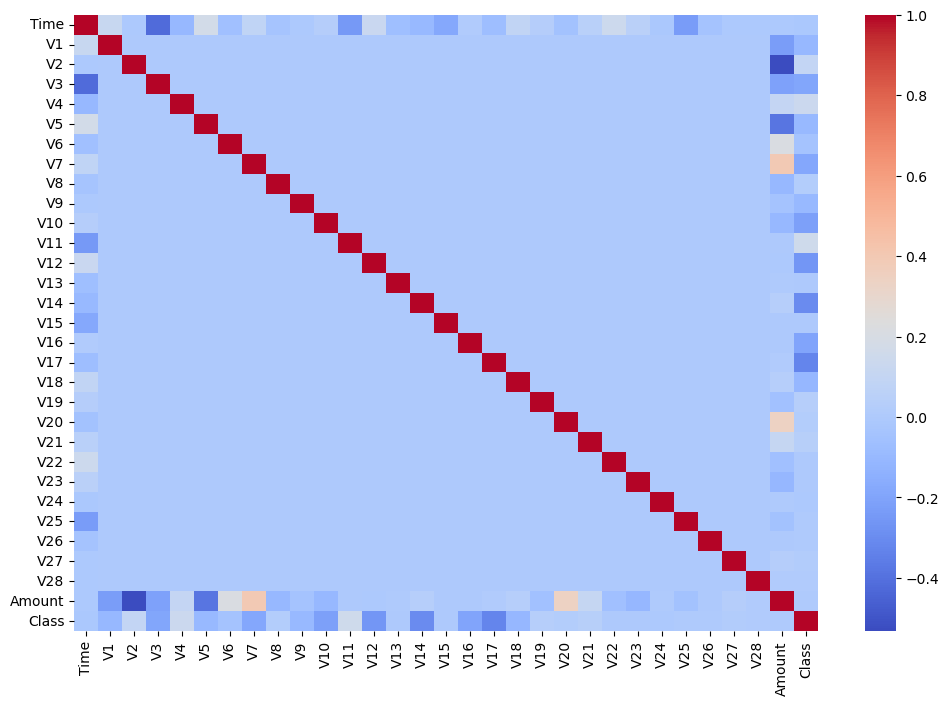

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.show()

## Step 7 — Feature Target Split

In [12]:
X = data.drop("Class", axis=1)
y = data["Class"]

## Step 8 — Train Test Split

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Step 9 — Handle Imbalance using SMOTE

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

## Handling Class Imbalance with SMOTE

SMOTE works by creating synthetic examples of the minority class (fraud cases).

Instead of duplicating fraud samples, it generates new samples by interpolating between existing fraud observations.

Advantages:
- Prevents model bias toward the majority class
- Improves fraud detection recall

## Step 10 — Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

## Model Comparison

In this project we compare three models:

1. Logistic Regression (baseline model)
2. Random Forest
3. Random Forest with Hyperparameter Tuning

The goal is to evaluate which model performs best for fraud detection.

Key metrics used:

- Precision
- Recall
- F1 Score
- ROC-AUC

## Step 11 — Logistic Regression Model

In [16]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_res_scaled, y_train_res)

LogisticRegression(max_iter=2000)

## Step 12 — Evaluate Logistic Regression

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_res_scaled, y_train_res)

LogisticRegression(max_iter=2000)

In [19]:
y_pred = log_model.predict(X_test_scaled)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.92      0.28        98

    accuracy                           0.99     56962
   macro avg       0.58      0.96      0.64     56962
weighted avg       1.00      0.99      0.99     56962



In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56400   464]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.92      0.28        98

    accuracy                           0.99     56962
   macro avg       0.58      0.96      0.64     56962
weighted avg       1.00      0.99      0.99     56962



## Step 13 — Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

## Step 14 — Evaluate Random Forest

In [ ]:
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

## Step 15 — Hyperparameter Tuning

## Hyperparameter Tuning

Hyperparameters are model parameters that are not learned automatically during training.

Examples for Random Forest include:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required to split a node (`min_samples_split`)

We use **GridSearchCV** to systematically test different parameter combinations and identify the best performing model.

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators':[100,200],'max_depth':[5,10],'min_samples_split':[2,5]}
grid = GridSearchCV(RandomForestClassifier(),param_grid,cv=3,scoring='f1')
grid.fit(X_train_res, y_train_res)
best_model = grid.best_estimator_
print(best_model)

RandomForestClassifier(max_depth=10)


## Cross Validation

Cross-validation evaluates the model on multiple splits of the dataset.

Instead of relying on a single train-test split, the dataset is divided into multiple folds and the model is trained and evaluated several times.

This helps ensure that the model generalizes well to unseen data.

## Step 16 — Evaluate Tuned Model

In [ ]:
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.88      0.73        98

    accuracy                           1.00     56962
   macro avg       0.81      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962



## Step 17 — ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score
y_prob = best_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print(roc_auc)

0.986774118412137


## ROC Curve Comparison

The ROC (Receiver Operating Characteristic) curve is used to evaluate the performance of classification models.

It plots:

True Positive Rate (Recall) vs False Positive Rate.

The **Area Under the Curve (AUC)** measures how well the model distinguishes between fraudulent and normal transactions.

A higher AUC score indicates better model performance.

In this section we compare the ROC curves of:

1. Logistic Regression
2. Random Forest
3. Random Forest with Hyperparameter Tuning

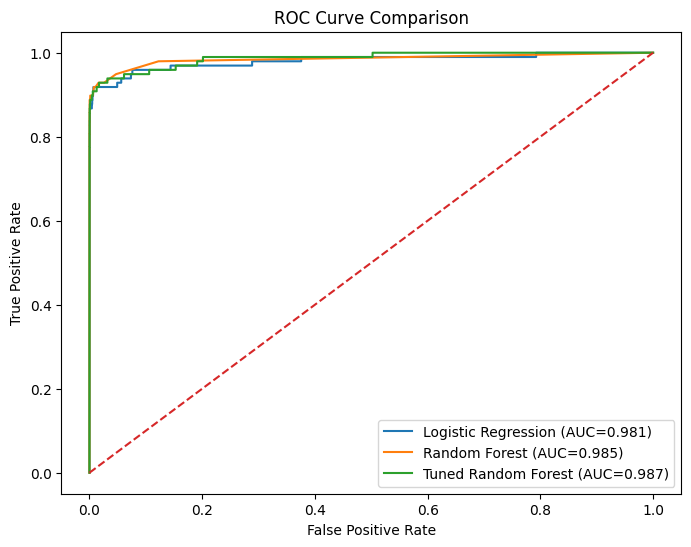

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression probabilities
log_probs = log_model.predict_proba(X_test_scaled)[:,1]

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test)[:,1]

# Tuned Random Forest probabilities
rf_tuned_probs = best_model.predict_proba(X_test)[:,1]

# ROC curve
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_tuned_fpr, rf_tuned_tpr, _ = roc_curve(y_test, rf_tuned_probs)

# AUC scores
log_auc = roc_auc_score(y_test, log_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
rf_tuned_auc = roc_auc_score(y_test, rf_tuned_probs)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC={log_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(rf_tuned_fpr, rf_tuned_tpr, label=f"Tuned Random Forest (AUC={rf_tuned_auc:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()


### Why use ROC instead of accuracy
Because fraud datasets are highly imbalanced, accuracy alone can be misleading. ROC-AUC measures the model’s ability to distinguish fraud and non-fraud transactions across different thresholds

## Step 18 — Feature Importance

In [ ]:
importance = best_model.feature_importances_
importance

array([0.0055172 , 0.01029127, 0.02815168, 0.07188802, 0.14311526,
       0.00616874, 0.02013862, 0.03548086, 0.00414569, 0.02111627,
       0.10399829, 0.07869079, 0.07068716, 0.00245163, 0.21475282,
       0.00260264, 0.04142084, 0.08854969, 0.01302204, 0.00337052,
       0.00242988, 0.01315212, 0.00166459, 0.00216436, 0.00173293,
       0.00206288, 0.00210165, 0.00216654, 0.00407373, 0.00289129])

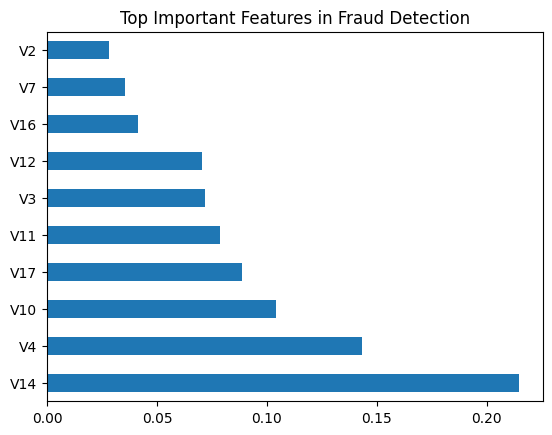

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_model.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)

feat_importance.nlargest(10).plot(kind='barh')

plt.title("Top Important Features in Fraud Detection")

plt.show()

## Feature Importance

Feature importance helps us understand which variables influence fraud detection most.

This improves model interpretability and helps financial institutions understand suspicious transaction patterns.

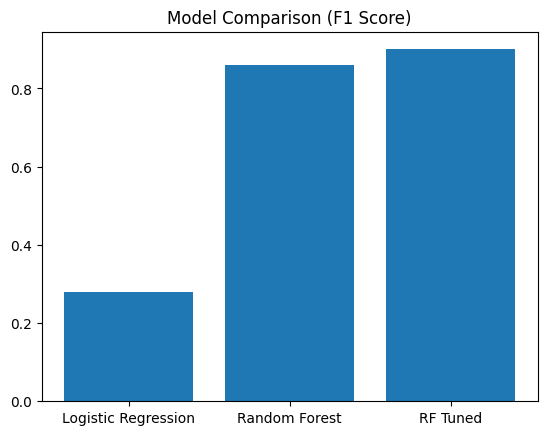

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression','Random Forest','RF Tuned']
f1_scores = [0.28,0.86,0.90]

plt.bar(models,f1_scores)
plt.title("Model Comparison (F1 Score)")
plt.show()

## Step 19 — Save Model

In [ ]:
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

## Model Saving

After training the best model, we save it using Joblib.

This allows the model to be reused for real-time fraud detection without retraining.

In [ ]:
import joblib
joblib.dump(best_model,'fraud_model.pkl')

['fraud_model.pkl']

## Conclusion

In this project we built a fraud detection system using machine learning.

Key achievements:

- Handled class imbalance using SMOTE
- Compared multiple models
- Improved performance using hyperparameter tuning
- Achieved strong fraud detection performance using Random Forest

Future improvements:

- Deploy the model as an API
- Use deep learning models
- Implement real-time fraud detection pipelines